## UFMFRR-15-M Machine Vision
# Tutorial 5 - Image Convolution

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import skimage.util as util
from scipy import ndimage
from skimage.exposure import rescale_intensity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# The function for convolving a source image with a kernel

In [ ]:
def convolve(img, kernel):
	# check dimensions
  (sh, sw) = img.shape[:2]
  (kh, kw) = kernel.shape[:2]
	# use padding to keep original size
  pad = (kw - 1) // 2
  img = cv2.copyMakeBorder(img, pad, pad, pad, pad,
		cv2.BORDER_REPLICATE)
	# the output can contain float point values
  output = np.zeros((sh, sw), dtype="float32")

  for y in np.arange(pad, sh + pad):
    for x in np.arange(pad, sw + pad):
			# crop a square around the centre pixel
      roi = img[y - pad:y + pad + 1, x - pad:x + pad + 1]
			# sum all values from element-wise multiplications
      k = (roi * kernel).sum()
			# replace original pixel value with convolution results
      output[y - pad, x - pad] = k

      	# make sure the range is still 0-255
  output = rescale_intensity(output, in_range=(0, 255))
  output = (255 * output ).astype("uint8")

  return output

# Add salt & pepper noise/Gaussian noise to an image

* Read an image and conver to greyscale

In [ ]:
rose = cv2.imread('/content/drive/MyDrive/Colab/rose.jpg')
grey = cv2.cvtColor(rose, cv2.COLOR_RGB2GRAY)

* Add salt and pepper noise

In [ ]:
grey_sp = util.random_noise(grey, 's&p', clip=True)

* Results returned was scaled between 0 and 1. Change it to 0 and 255

In [ ]:
grey_sp = (grey_sp*255).astype(np.uint8)
cv2_imshow(grey_sp)

* Add Gaussian noise

In [ ]:
grey_gauss = util.random_noise(grey, 'gaussian', clip=True)
grey_gauss = (grey_gauss*255).astype(np.uint8)
cv2_imshow(grey_gauss)

# Convolution

In [ ]:
# kernel as a 3 by 3 average filter
kernel_avg = 1/9 * np.array((
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]), dtype="int")

# kernel as a 5 by 5 average filter
kernel_avg2 = np.ones((5, 5))/25

# use the average filter to denoise Gaussian noise
convoleOutput = convolve(grey_gauss, kernel_avg2)

# show results
cv2_imshow(convoleOutput)

# use the average filter to denoise s&p noise
convoleOutput = convolve(grey_sp, kernel_avg2)

# show results
cv2_imshow(convoleOutput)

# use a median filter to denoise s&p noise
med_denoised = ndimage.median_filter(grey_sp, 5)
cv2_imshow(med_denoised)

# How to use different kernels in convolution?

### *The codes in this chapter are not completed. Please use the knowledge learned this week to finish the following tasks.*

Imagine that you are a player in the three-body game. You plan to use Machine Vision to study the motion of the three suns and the only planet in the three-body galaxy. The following code will give you a photo of the galaxy, where you can see the three largest round suns, one smaller planet and millions of stars in the Milky Way. When you use the following codes to generate an image, the three suns and the planet may overlap due to their relative position. To avoid overlaps, you can run the code multiple times to find the best one for your experiment.



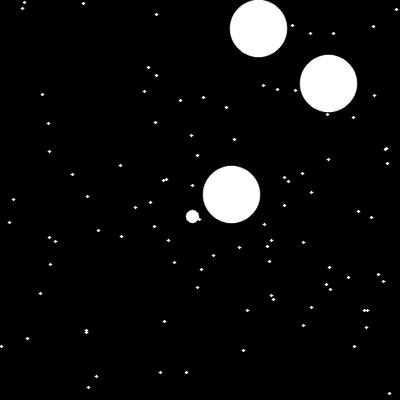

In [ ]:
# Magic code to geneate a photo of a three-body galaxy
import random
import math

# The universe background
galaxy_image = np.zeros((400, 400, 1), dtype=np.uint8)

# Generate stars and planets in the image
for k in range(100):
  # The Milky Way stars
  cv2.circle(galaxy_image, (round(400*random.random()),round(400*random.random())), 1, 255, -1, lineType=cv2.LINE_AA)
for i in range(3):
  # The three suns
  cv2.circle(galaxy_image, (round(400*random.random()),round(360*random.random())), 28, 255, -1, lineType=cv2.LINE_AA)
for j in range(1):
  # The three-body planet
  cv2.circle(galaxy_image, (round(400*random.random()),round(400*random.random())), 6, 255, -1, lineType=cv2.LINE_AA)

cv2_imshow(galaxy_image)

**Task 1.** Average filter vs. [Gaussian filter](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html)

Gaussian filter is a filter that has a similar function to the average filter. Please process the galaxy image using the same-sized average filter and Gaussian filter and discuss differences in your results with your group members.


In [ ]:
# Start to write your code here...

**Task 2.** Detect stars, three suns and the planet using image processing

Do you know that instead of using morphological operations, you can use image convolutions to detect the three suns, stars and the planet in the galaxy image as well? Please use a series of [Gaussian filters](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html) with the [Laplacian corner detector](https://docs.opencv.org/3.4/d5/db5/tutorial_laplace_operator.html) to detect the stats and the planet in the image.

**Hints:** 1) You can process the image using Gaussian filters with different sizes and observe the impact of kernel size on the output image from the Laplacian operations. 2) Check your result images carefully. If the elements in the image are barely visible, you can use the image processing methods you have learned, such as Histogram Equalisation, Thresholding, and some Morphological Operations to enhance the image. 3) Do you think subtracting one output image from another would be helpful in this detection? Please write codes to test it and record your reflections on these experiments.


In [ ]:
# Start to write your code here...

# Extension - edge and corner detection operator

* Canny edge detector

In [ ]:
edges = cv2.Canny(np.uint8(grey),200,400)  # 200, 400 here are the double thresholds used for hysteresis analysis
cv2_imshow(edges)

* Harris corner detector

In [ ]:
grey = np.float32(grey_sp)
dst = cv2.cornerHarris(grey, blockSize=3, ksize=1, k=0.06)
# blockSize - the size of neighbourhood considered for corner detection,
# ksize - Aperture parameter of Sobel derivative used,
# k - Harris detector free parameter in the equation. Normally a smaller k gives you more corners.
cv2_imshow(dst)
# result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)
# Threshold for an optimal value, it may vary depending on the image.
rose[dst>0.5*dst.max()] = [0,0,255]
cv2_imshow(rose)